In [21]:
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
#import pooch
import scanpy as sc
import scvi
import torch
import pandas as pd

In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
sc.set_figure_params(figsize=(4, 4), frameon=False)
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor" : "w"}
%config InlineBackend.figure_format="retina"

Seed set to 0


Last run with scvi-tools version: 1.1.2


In [63]:
sc.settings.figdir = "../result/intergrate/"

In [4]:
adata = sc.read("../process/framework/obj/combined_E12_E14_signc_sceasy.h5ad")

In [5]:
print("# regions before filtering:", adata.shape[-1])

# compute the threshold: 5% of the cells
min_cells = int(adata.shape[0] * 0.05)
# in-place filtering of regions
sc.pp.filter_genes(adata, min_cells=min_cells)

print("# regions after filtering:", adata.shape[-1])

# regions before filtering: 297386
# regions after filtering: 32923


In [6]:
scvi.model.PEAKVI.setup_anndata(adata,batch_key = "batch")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [9]:
model = scvi.model.PEAKVI(adata)
model.train(max_epochs = 20)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 20/20: 100%|██████████| 20/20 [49:05<00:00, 146.99s/it, v_num=1, train_loss_step=6.01e+7, train_loss_epoch=1.69e+8]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [49:05<00:00, 147.25s/it, v_num=1, train_loss_step=6.01e+7, train_loss_epoch=1.69e+8]


In [8]:
model

PeakVI Model with params: 
n_hidden: 181, n_latent: 13, n_layers_encoder: 2, n_layers_decoder: 2 , dropout_rate: 0.1, latent_distribution: 
normal, deep injection: False, encode_covariates: False
Training status: Trained

In [10]:
model

PeakVI Model with params: 
n_hidden: 181, n_latent: 13, n_layers_encoder: 2, n_layers_decoder: 2 , dropout_rate: 0.1, latent_distribution: 
normal, deep injection: False, encode_covariates: False
Training status: Trained

In [11]:
!mkdir ../process/integration

In [12]:
!mkdir ../process/integration/peakvi

In [13]:
model_dir = os.path.join("../process/integration/peakvi", "peakvi_20_epoch")
model.save(model_dir, overwrite=True)

In [14]:
PEAKVI_LATENT_KEY = "X_peakvi"

latent = model.get_latent_representation()
adata.obsm[PEAKVI_LATENT_KEY] = latent
latent.shape

(42042, 13)

In [15]:
PEAKVI_CLUSTERS_KEY = "clusters_peakvi"

# compute the k-nearest-neighbor graph that is used in both clustering and umap algorithms
sc.pp.neighbors(adata, use_rep=PEAKVI_LATENT_KEY)
# compute the umap
sc.tl.umap(adata, min_dist=0.2)
# cluster the space (we use a lower resolution to get fewer clusters than the default)
sc.tl.leiden(adata, key_added=PEAKVI_CLUSTERS_KEY, resolution=0.2)

/tmp/ipykernel_1023017/192297472.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=PEAKVI_CLUSTERS_KEY, resolution=0.2)


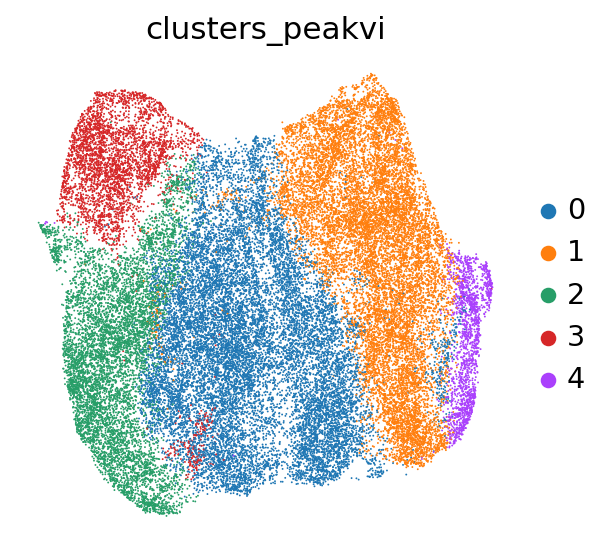

In [16]:
sc.pl.umap(adata, color=PEAKVI_CLUSTERS_KEY)

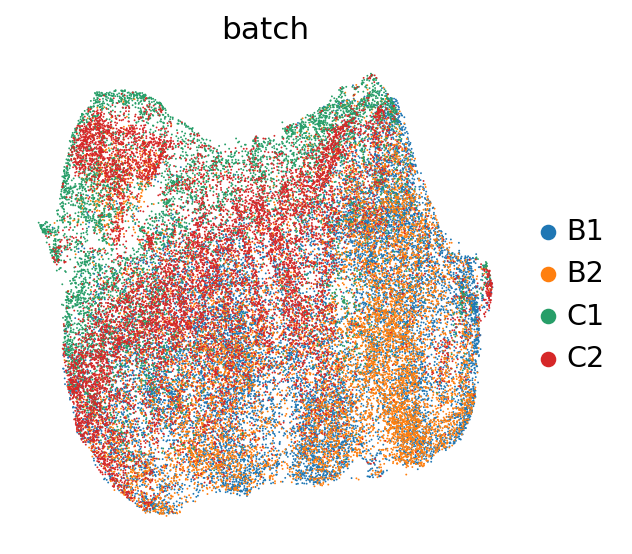

In [17]:
sc.pl.umap(adata, color="batch")

In [18]:
!mkdir ../process/framework/reduction

In [26]:
umap_df = pd.DataFrame(adata.obsm["X_umap"])
umap_df.index = adata.obs_names
umap_df.to_csv("../process/framework/reduction/7.17_combined_umap_20epcho.csv")

In [29]:
peakvi_df = pd.DataFrame(adata.obsm["X_peakvi"])
peakvi_df.index = adata.obs_names
peakvi_df.to_csv("../process/framework/reduction/7.17_combined_peakvi_20epcho.csv")

In [ ]:
model_full = scvi.model.PEAKVI(adata)
model_full.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 42/500:   8%|▊         | 41/500 [1:38:49<18:11:56, 142.74s/it, v_num=1, train_loss_step=6.31e+7, train_loss_epoch=1.68e+8]

In [ ]:
model_dir = os.path.join("../process/integration/peakvi", "peakvi_full_epoch")
model_full.save(model_dir, overwrite=True)

In [33]:
PEAKVI_LATENT_KEY = "X_peakvi_full"

latent = model_full.get_latent_representation()
adata.obsm[PEAKVI_LATENT_KEY] = latent
latent.shape

(42042, 13)

In [34]:
PEAKVI_CLUSTERS_KEY = "clusters_peakvi_full"

# compute the k-nearest-neighbor graph that is used in both clustering and umap algorithms
sc.pp.neighbors(adata, use_rep=PEAKVI_LATENT_KEY)
# compute the umap
sc.tl.umap(adata, min_dist=0.2)
# cluster the space (we use a lower resolution to get fewer clusters than the default)
sc.tl.leiden(adata, key_added=PEAKVI_CLUSTERS_KEY, resolution=0.2)

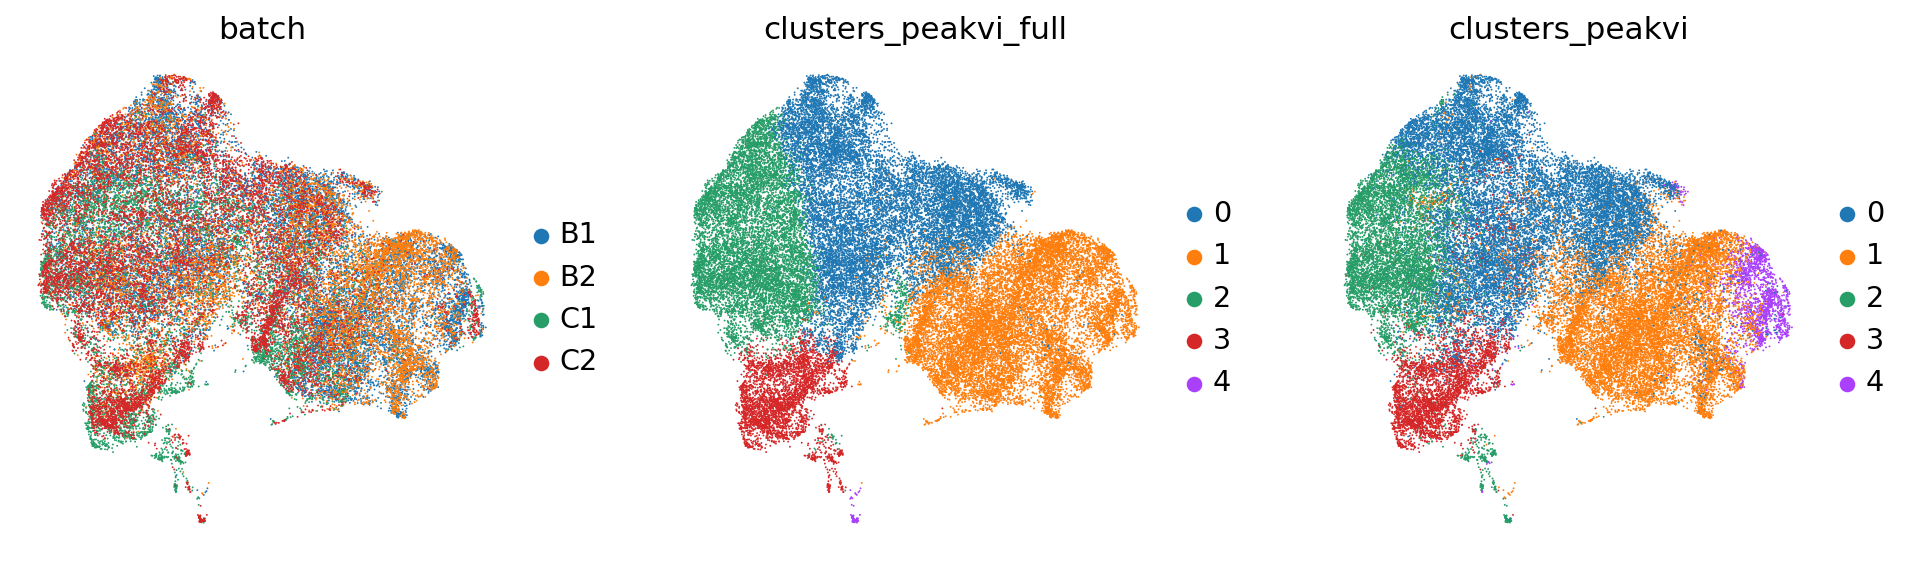

In [37]:
sc.pl.umap(adata, color=["batch","clusters_peakvi_full","clusters_peakvi"])

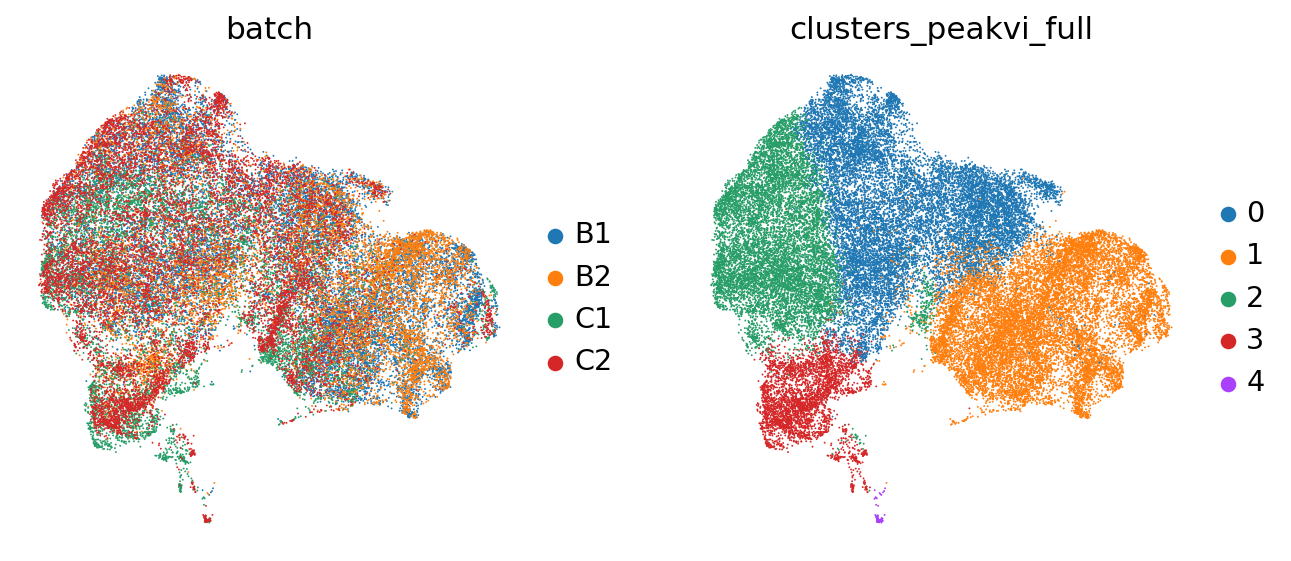

In [64]:
sc.pl.umap(adata, color=["batch","clusters_peakvi_full"],save="_peakvi_umap_batch")

In [38]:
peakvi_df = pd.DataFrame(adata.obsm["X_peakvi_full"])
peakvi_df.index = adata.obs_names
peakvi_df.to_csv("../process/framework/reduction/7.17_combined_peakvi_full.csv")

In [39]:
umap_df = pd.DataFrame(adata.obsm["X_umap"])
umap_df.index = adata.obs_names
umap_df.to_csv("../process/framework/reduction/7.17_combined_umap_full.csv")

In [40]:
pd.DataFrame(adata.obs["clusters_peakvi_full"]).to_csv("../process/framework/cluster/combine_peakvi.csv")

In [48]:
grouped=adata.obs.groupby(["clusters_peakvi_full","batch"]).size().reset_index(name='count')

In [53]:
grouped

,clusters_peakvi_full,batch,count,total,percent
0,0,B1,5901,14322,41.202346
1,0,B2,3462,14322,24.172602
2,0,C1,1386,14322,9.677419
3,0,C2,3573,14322,24.947633
4,1,B1,6107,13993,43.643250
5,1,B2,4702,13993,33.602516
6,1,C1,1433,13993,10.240835
7,1,C2,1751,13993,12.513400
8,2,B1,2659,9926,26.788233
9,2,B2,1475,9926,14.859964


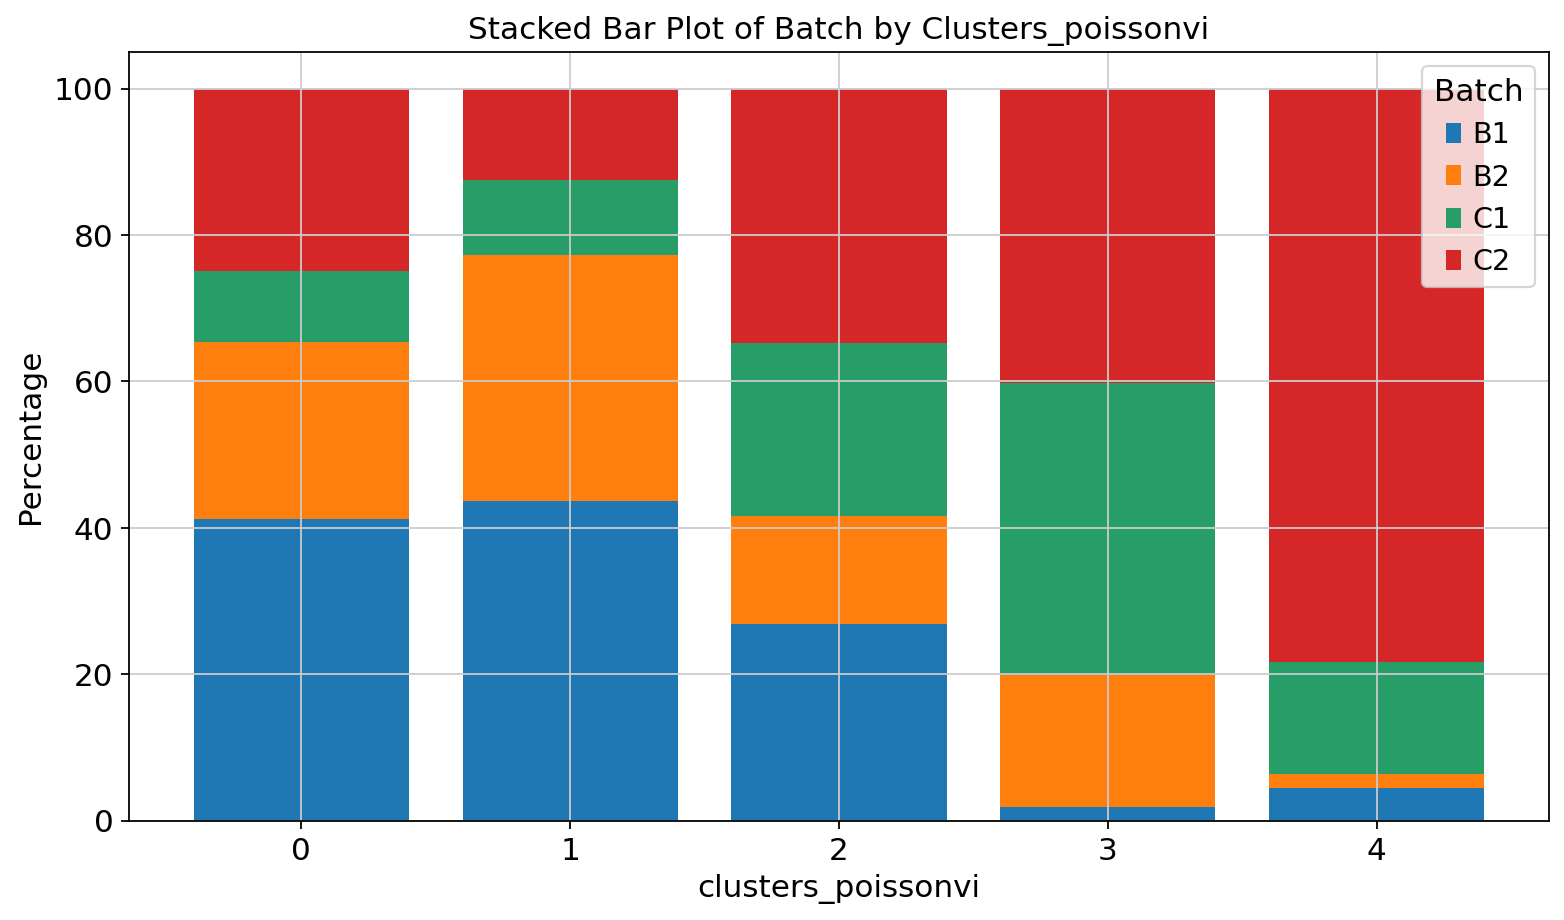

In [62]:
grouped2=adata.obs.groupby(["clusters_peakvi_full","batch"]).size().reset_index(name='count')
df = grouped2
df_pivot = df.pivot_table(values='count', index='batch', columns='clusters_peakvi_full', aggfunc='sum', fill_value=0)
df_pivot = df_pivot.div(df_pivot.sum(axis=0), axis=1) * 100

df = df_pivot
# Plotting
plt.figure(figsize=(10, 6))

# Stacked bar plot
bottom = None
for batch in df.index:
    plt.bar(df.columns, df.loc[batch], bottom=bottom, label=batch)
    if bottom is None:
        bottom = df.loc[batch].values
    else:
        bottom += df.loc[batch].values

plt.xlabel('clusters_poissonvi')
plt.ylabel('Percentage')
plt.title('Stacked Bar Plot of Batch by Clusters_poissonvi')
plt.xticks(df.columns)
plt.legend(title='Batch')
plt.tight_layout()
plt.savefig("../result/intergrate/peakvi_integrate.pdf")
plt.show()

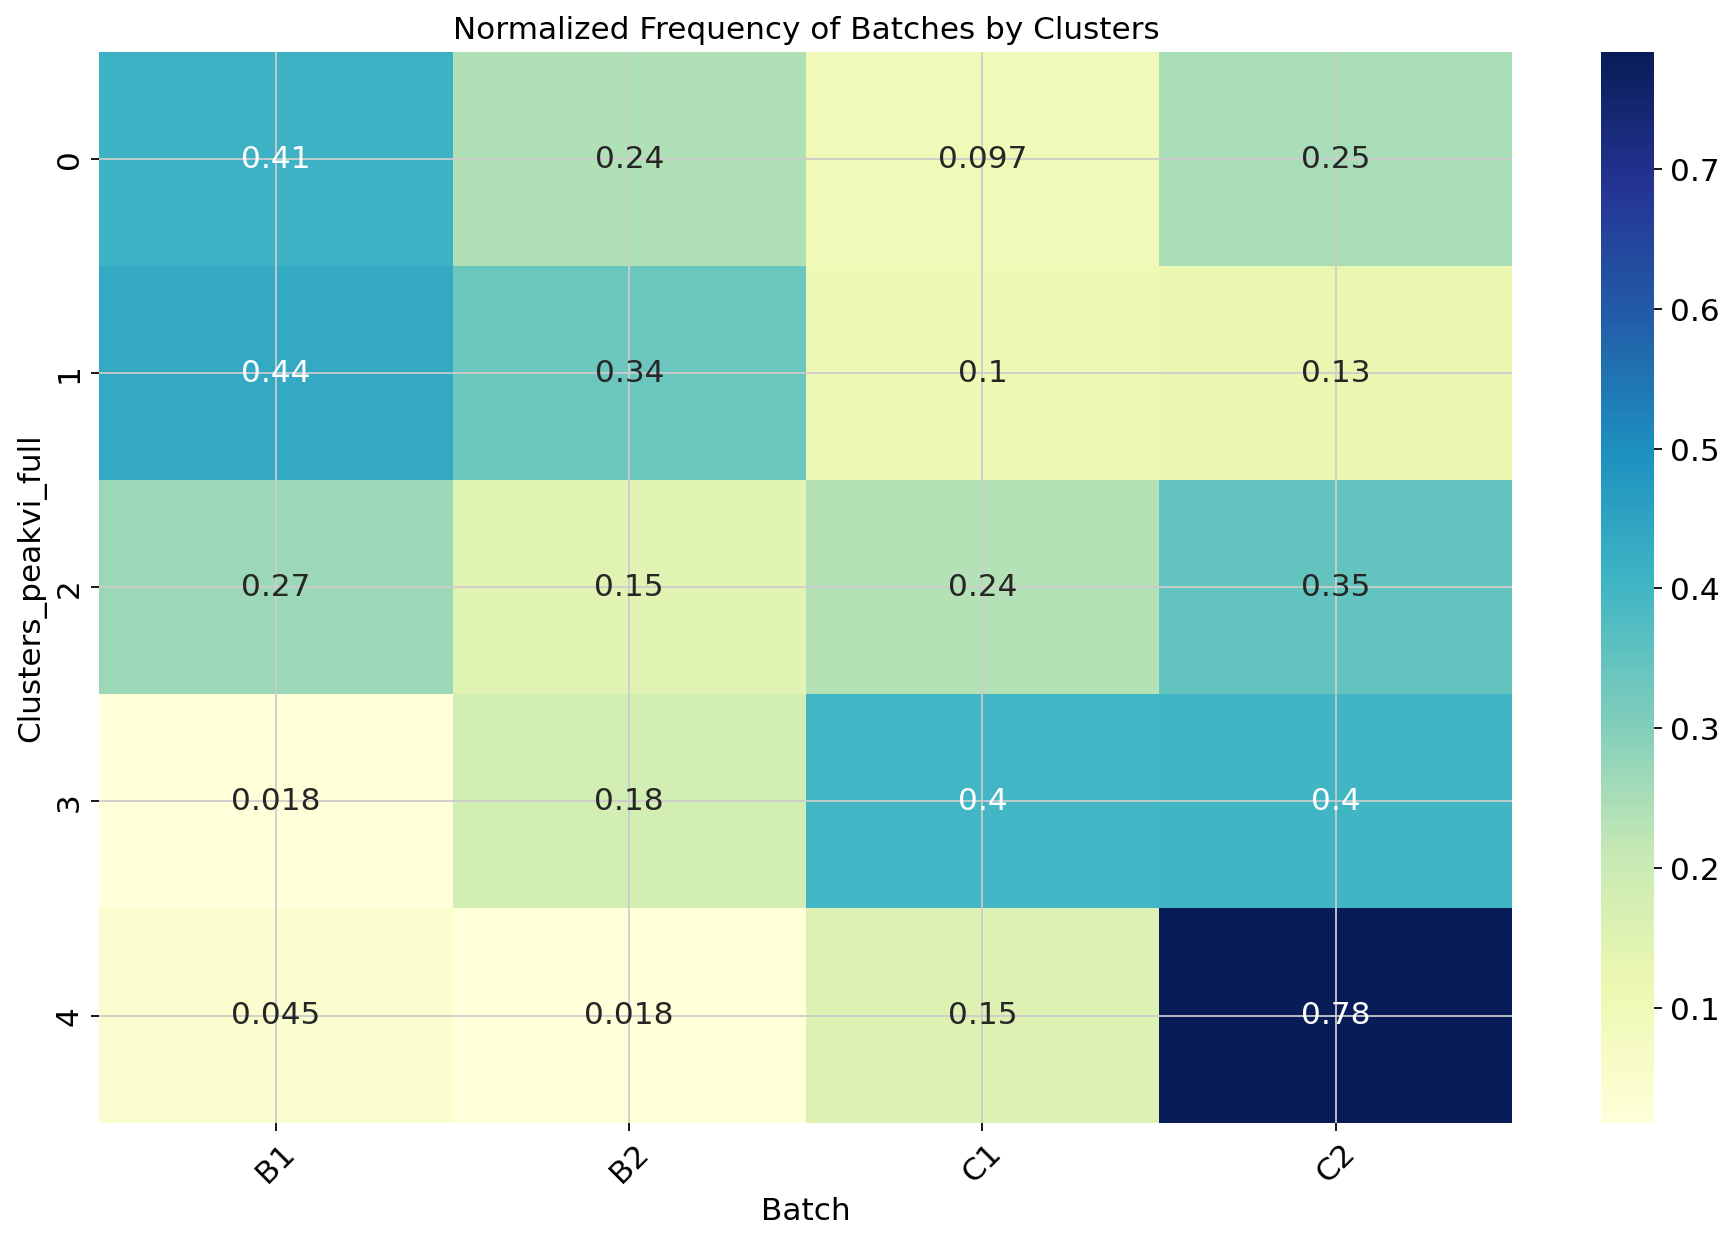

In [54]:
# Pivot the table to have 'clusters_peakvi_full' as rows, 'batch' as columns, and 'count' as values
pivot_table = grouped.pivot(index='clusters_peakvi_full', columns='batch', values='count')

# Normalize each row to sum up to 1
pivot_table = pivot_table.div(pivot_table.sum(axis=1), axis=0)

# Plotting heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", cbar=True)
plt.title('Normalized Frequency of Batches by Clusters')
plt.xlabel('Batch')
plt.ylabel('Clusters_peakvi_full')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
da_peaks_1 = model.differential_accessibility(
    adata, groupby="clusters_peakvi_full", group1="1", two_sided=False
)

DE...: 100%|██████████| 1/1 [01:15<00:00, 75.64s/it]


In [66]:
da_peaks_1

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr13-72710863-72711739,0.9372,False,2.702941,-0.358292,-0.092104,0.458604,0.100312,0.118059,0.025955
chr13-72763087-72764133,0.9330,False,2.633712,-0.280817,-0.069561,0.370750,0.089933,0.097263,0.027702
chr4-117104913-117105883,0.9132,False,2.353348,-0.306544,-0.071224,0.423453,0.116909,0.107125,0.035901
chr14-56240913-56241856,0.9086,False,2.296659,-0.310439,-0.077075,0.403799,0.093360,0.109340,0.032265
chr11-33871850-33873566,0.9028,False,2.228730,-0.369154,-0.084029,0.602052,0.232898,0.157436,0.073407
...,...,...,...,...,...,...,...,...,...
chr5-20881414-20882724,0.0000,False,-18.420681,0.002510,0.115730,0.996102,0.998612,0.331380,0.447110
chr12-70824819-70826005,0.0000,False,-18.420681,0.005881,0.109612,0.991189,0.997070,0.309512,0.419124
chr12-71015182-71016196,0.0000,False,-18.420681,0.000742,0.104468,0.997922,0.998664,0.329808,0.434276
chr12-72085286-72086302,0.0000,False,-18.420681,0.001065,0.106062,0.997882,0.998946,0.350389,0.456451


In [68]:
da_peaks_1_filt = da_peaks_1[(da_peaks_1.emp_prob1 >= 0.05)]

In [69]:
da_peaks_1_filt

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr13-72710863-72711739,0.9372,False,2.702941,-0.358292,-0.092104,0.458604,0.100312,0.118059,0.025955
chr13-72763087-72764133,0.9330,False,2.633712,-0.280817,-0.069561,0.370750,0.089933,0.097263,0.027702
chr4-117104913-117105883,0.9132,False,2.353348,-0.306544,-0.071224,0.423453,0.116909,0.107125,0.035901
chr14-56240913-56241856,0.9086,False,2.296659,-0.310439,-0.077075,0.403799,0.093360,0.109340,0.032265
chr11-33871850-33873566,0.9028,False,2.228730,-0.369154,-0.084029,0.602052,0.232898,0.157436,0.073407
...,...,...,...,...,...,...,...,...,...
chr5-20881414-20882724,0.0000,False,-18.420681,0.002510,0.115730,0.996102,0.998612,0.331380,0.447110
chr12-70824819-70826005,0.0000,False,-18.420681,0.005881,0.109612,0.991189,0.997070,0.309512,0.419124
chr12-71015182-71016196,0.0000,False,-18.420681,0.000742,0.104468,0.997922,0.998664,0.329808,0.434276
chr12-72085286-72086302,0.0000,False,-18.420681,0.001065,0.106062,0.997882,0.998946,0.350389,0.456451


In [72]:
da_peaks_1_filt.index[:4]

Index(['chr13-72710863-72711739', 'chr13-72763087-72764133',
       'chr4-117104913-117105883', 'chr14-56240913-56241856'],
      dtype='object')

In [73]:
da_res1_vs_3 = model.differential_accessibility(
    groupby=PEAKVI_CLUSTERS_KEY, group1="1", group2="3", two_sided=True
)

DE...: 100%|██████████| 1/1 [00:42<00:00, 42.39s/it]


In [74]:
da_res1_vs_3

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr13-60044696-60045726,0.9988,True,6.724225,-0.619479,-0.181109,0.700905,0.081426,0.197099,0.015989
chr3-127842873-127843800,0.9986,True,6.569875,-0.559301,-0.145470,0.618145,0.058844,0.157936,0.012466
chr7-28083907-28085230,0.9980,True,6.212601,-0.506045,-0.124382,0.602937,0.096891,0.161509,0.037127
chr5-128700373-128701298,0.9976,True,6.029880,-0.406769,-0.091468,0.484865,0.078097,0.116129,0.024661
chr15-5446289-5447585,0.9974,True,5.949637,-0.464834,-0.105315,0.516242,0.051408,0.128350,0.023035
...,...,...,...,...,...,...,...,...,...
chr9-14675645-14676881,0.0000,False,-18.420681,0.006977,0.178788,0.990101,0.997078,0.290860,0.469648
chr9-20642414-20643465,0.0000,False,-18.420681,0.002396,0.130238,0.994409,0.996805,0.296863,0.427100
chr9-20651500-20652422,0.0000,False,-18.420681,0.003803,0.156350,0.991208,0.995010,0.305438,0.461789
chr9-21290882-21291834,0.0000,False,-18.420681,0.000983,0.226951,0.997440,0.998424,0.334024,0.560976


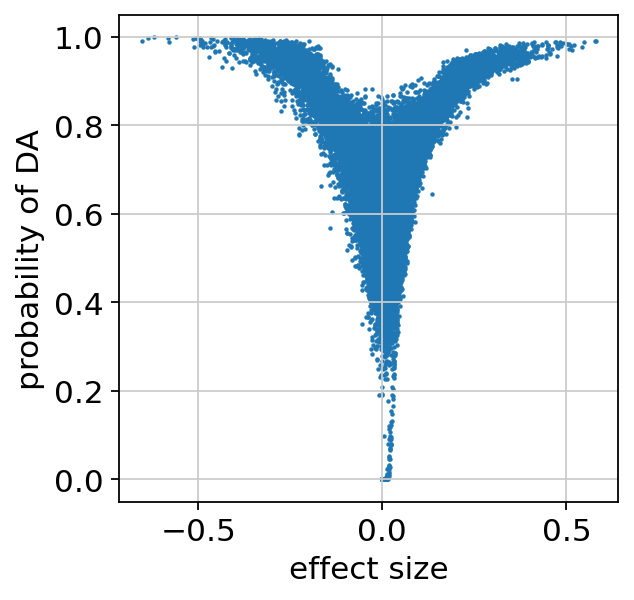

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr13-60044696-60045726,0.9988,True,6.724225,-0.619479,-0.181109,0.700905,0.081426,0.197099,0.015989
chr3-127842873-127843800,0.9986,True,6.569875,-0.559301,-0.145470,0.618145,0.058844,0.157936,0.012466
chr7-28083907-28085230,0.9980,True,6.212601,-0.506045,-0.124382,0.602937,0.096891,0.161509,0.037127
chr5-128700373-128701298,0.9976,True,6.029880,-0.406769,-0.091468,0.484865,0.078097,0.116129,0.024661
chr15-5446289-5447585,0.9974,True,5.949637,-0.464834,-0.105315,0.516242,0.051408,0.128350,0.023035
chr10-110750777-110751698,0.9972,True,5.875328,-0.336183,-0.081836,0.403043,0.066860,0.100264,0.018428
chr6-117246879-117247858,0.9968,True,5.741396,-0.411292,-0.103898,0.466774,0.055482,0.119345,0.015447
chr4-107819845-107821200,0.9966,True,5.680571,-0.394884,-0.094672,0.477916,0.083032,0.120417,0.025745
chr8-106768867-106769962,0.9966,True,5.680571,-0.581821,-0.138570,0.681654,0.099833,0.180304,0.041734
chr5-128649314-128650229,0.9964,True,5.623212,-0.636500,-0.167708,0.763651,0.127151,0.220825,0.053117


In [77]:
plt.scatter(da_res1_vs_3.effect_size, da_res1_vs_3.prob_da, s=1)
plt.xlabel("effect size")
plt.ylabel("probability of DA")
plt.show()

da_res1_vs_3.loc[da_res1_vs_3.is_da_fdr].sort_values("prob_da", ascending=False).head(10)

In [78]:
da_res1_vs_3.to_csv()

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr13-60044696-60045726,0.9988,True,6.724225,-0.619479,-0.181109,0.700905,0.081426,0.197099,0.015989
chr3-127842873-127843800,0.9986,True,6.569875,-0.559301,-0.145470,0.618145,0.058844,0.157936,0.012466
chr7-28083907-28085230,0.9980,True,6.212601,-0.506045,-0.124382,0.602937,0.096891,0.161509,0.037127
chr5-128700373-128701298,0.9976,True,6.029880,-0.406769,-0.091468,0.484865,0.078097,0.116129,0.024661
chr15-5446289-5447585,0.9974,True,5.949637,-0.464834,-0.105315,0.516242,0.051408,0.128350,0.023035
...,...,...,...,...,...,...,...,...,...
chr9-14675645-14676881,0.0000,False,-18.420681,0.006977,0.178788,0.990101,0.997078,0.290860,0.469648
chr9-20642414-20643465,0.0000,False,-18.420681,0.002396,0.130238,0.994409,0.996805,0.296863,0.427100
chr9-20651500-20652422,0.0000,False,-18.420681,0.003803,0.156350,0.991208,0.995010,0.305438,0.461789
chr9-21290882-21291834,0.0000,False,-18.420681,0.000983,0.226951,0.997440,0.998424,0.334024,0.560976


In [79]:
da_res1_vs_3.to_csv("../process/differential_peak/7.18_peak_vi_cluster1_vs_3.csv")

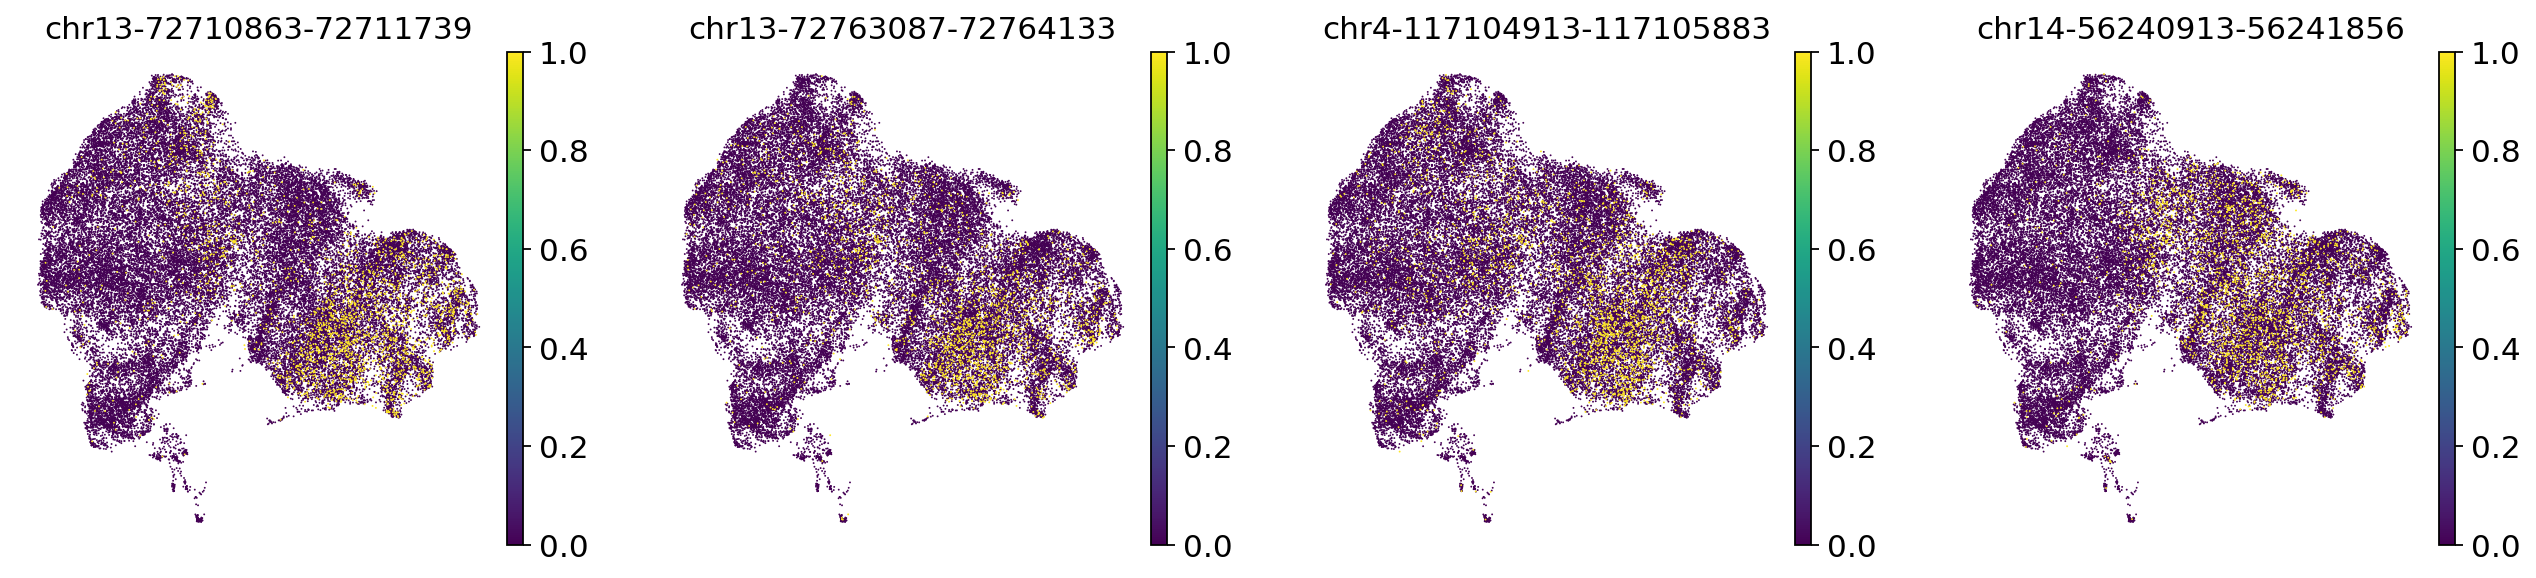

In [71]:
sc.pl.umap(adata, color=da_peaks_1_filt.index[:4], vmax="p99.0")

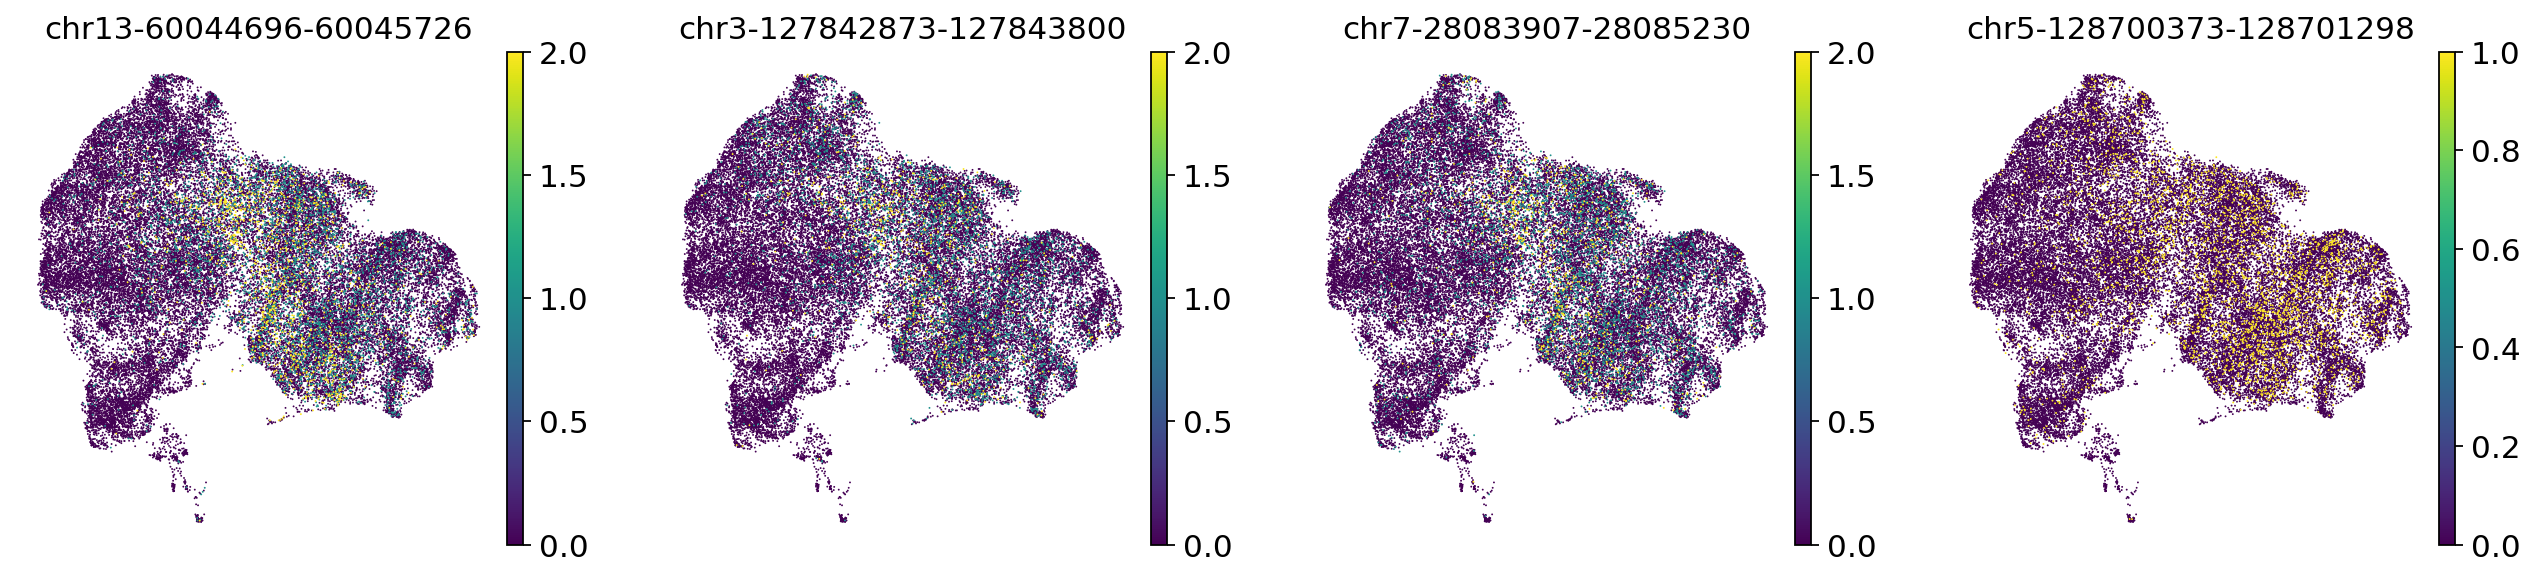

In [80]:
sc.pl.umap(adata, color=da_res1_vs_3.index[:4], vmax="p99.0")

In [84]:
adata.obs["batch"].isin(['C1', 'C2'])

B1_AAACGAAAGAATACTG-1    False
B1_AAACGAAAGACGACTG-1    False
B1_AAACGAAAGAGAGTTT-1    False
B1_AAACGAAAGCCTTTGA-1    False
B1_AAACGAAAGCGTGTTT-1    False
                         ...  
C2_TTTGTGTGTAGCGAGT-1     True
C2_TTTGTGTGTCCTATTT-1     True
C2_TTTGTGTTCCATCTAT-1     True
C2_TTTGTGTTCCGTGCAG-1     True
C2_TTTGTGTTCGTTGTAG-1     True
Name: batch, Length: 42042, dtype: bool

In [85]:
da_resE12_vs_E14 = model.differential_accessibility(
    groupby="batch",idx1=adata.obs["batch"].isin(['C1', 'C2']),
    idx2=adata.obs["batch"].isin(['B1', 'B2']), two_sided=True
)

DE...: 100%|██████████| 1/1 [01:24<00:00, 84.89s/it]


In [101]:
da_resE12_vs_E14.to_csv("../process/differential_peak/E12_E14_diff.csv")

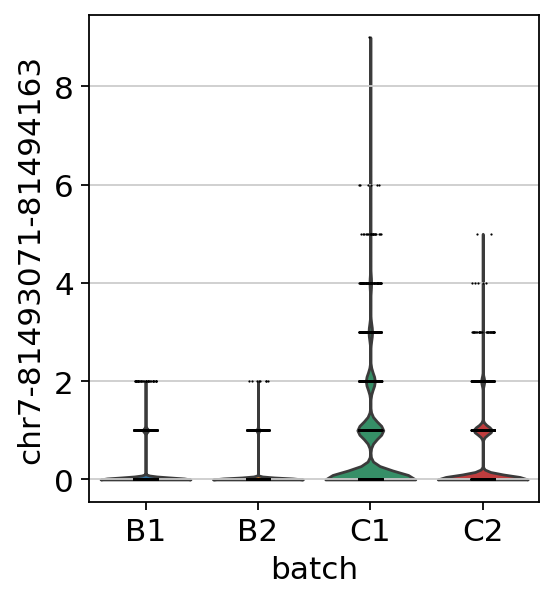

In [87]:
sc.pl.violin(adata,groupby="batch",keys="chr7-81493071-81494163")

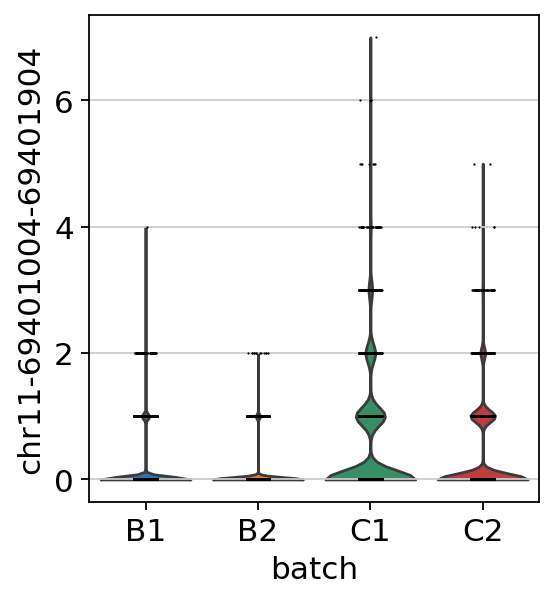

In [89]:
sc.pl.violin(adata,groupby="batch",keys="chr11-69401004-69401904")

In [90]:
da_peaks_0 = model.differential_accessibility(
    adata, groupby="clusters_peakvi_full", group1="0", two_sided=False
)
da_peaks_2 = model.differential_accessibility(
    adata, groupby="clusters_peakvi_full", group1="2", two_sided=False
)

DE...: 100%|██████████| 1/1 [01:12<00:00, 72.26s/it]


In [91]:
da_peaks_3 = model.differential_accessibility(
    adata, groupby="clusters_peakvi_full", group1="3", two_sided=False
)
da_peaks_4 = model.differential_accessibility(
    adata, groupby="clusters_peakvi_full", group1="4", two_sided=False
)

DE...: 100%|██████████| 1/1 [00:58<00:00, 58.93s/it]


In [97]:
da_peaks_0_filt = da_peaks_0[(da_peaks_0.emp_prob1 >= 0.1)]
da_peaks_2_filt = da_peaks_2[(da_peaks_2.emp_prob1 >= 0.1)]
da_peaks_3_filt = da_peaks_3[(da_peaks_3.emp_prob1 >= 0.1)]
da_peaks_4_filt = da_peaks_4[(da_peaks_4.emp_prob1 >= 0.1)]

In [99]:
da_peaks_2_filt

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
chr8-102116473-102117965,0.9248,False,2.509426,-0.374838,-0.157379,0.443176,0.068338,0.181946,0.024567
chr6-6658833-6659980,0.9172,False,2.404897,-0.362917,-0.147239,0.457698,0.094782,0.176103,0.028864
chr13-9973511-9974777,0.9146,False,2.371141,-0.333925,-0.125013,0.429462,0.095537,0.155652,0.030639
chr17-67226780-67227801,0.9126,False,2.345802,-0.371214,-0.164840,0.495474,0.124260,0.209148,0.044308
chr16-57235380-57236492,0.9110,False,2.325906,-0.333707,-0.133084,0.434839,0.101133,0.168144,0.035060
...,...,...,...,...,...,...,...,...,...
chr7-19715252-19716345,0.0000,False,-18.420681,-0.000183,-0.099162,0.999307,0.999124,0.543925,0.444763
chr7-24883855-24884820,0.0000,False,-18.420681,-0.000144,-0.084046,0.999111,0.998968,0.500101,0.416054
chr7-25076723-25077747,0.0000,False,-18.420681,-0.000539,-0.099774,0.998475,0.997936,0.492444,0.392670
chr7-25267721-25268694,0.0000,False,-18.420681,-0.000090,-0.108584,0.999168,0.999079,0.515515,0.406931


In [100]:
da_peaks_0_filt.to_csv("../process/differential_peak/peakvi_cluster0_diff.csv")
da_peaks_1_filt.to_csv("../process/differential_peak/peakvi_cluster1_diff.csv")
da_peaks_2_filt.to_csv("../process/differential_peak/peakvi_cluster2_diff.csv")
da_peaks_3_filt.to_csv("../process/differential_peak/peakvi_cluster3_diff.csv")